# 基于上下文残差聚合的超高分辨率图像修复——CRA

## CRA概述

传统的图像修复方法只能处理低分辨率的输入图像，而对低分辨率修复结果进行简单的上采样只会产生大而模糊的结果。我们知道，在模糊图像上添加高频残差部分可以丰富图像的细节和纹理，基于此，论文（Contextual Residual Aggregation for Ultra High-Resolution Image Inpainting）提出了一种上下文残差聚合机制（CRA），将上下文聚合残差添加到上采样的神经网络修复结果来输出最终结果。通过注意力转移模块（ATM）从上下文残差和注意分数来计算掩模区域中的聚合残差，通过搭建生成对抗网络进行低分辨率的图像预测，很好地抑制了内存和计算时间的成本。此外，论文引入了一些其他技术来提高修复质量、计算速度，如：注意力分数共享、多尺度注意力转移机制、轻量级门控卷积（LWGC），最终，该模型可以高精度修复占有25%孔洞大小的大型图像（高达8K）。

## 准备环节

### 配置环境

本教程我们在GPU环境下，使用图模式运行实验。

In [1]:
from mindspore import context

#选择执行模式为图模式；指定训练使用的平台为"GPU"，如需使用昇腾硬件可将其替换为"Ascend"
context.set_context(mode=context.GRAPH_MODE, device_target='GPU')


[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:01.531.144 [mindspore/context.py:1401] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


### 准备数据

本案例使用places2数据集作为训练集。下载链接提供如下：
places2数据集：http://places2.csail.mit.edu/download.html ,在该官网中下载High-resolution images训练数据集，该数据集共有443个场景类别，包含超过180万张1024$\times$1024的图片。

mask数据集在https://github.com/duxingren14/Hifill-tensorflow/tree/master/mask_templates 下载，共包含100张掩膜图片，可使用两种方法动态生成不规则mask，或模拟撕裂、划痕、斑点等，或通过随机操作真实的对象形状模板来生成掩膜。

推理数据在https://github.com/duxingren14/Hifill-tensorflow/tree/master/data/test 下载，包含两组匹配的image图像和mask图像。

同时，下载链接https://github.com/duxingren14/Hifill-tensorflow/tree/master/data/examples/train 中的数据，包含16张图像，放到/examples目录，用于案例CRA.ipynb测试。

将解压后数据集放到CRA目录下，文件目录如下所示：

```text
  CRA
   ├── places
           ├── a
               ├── auto_showroom
                         ├── 00000001.jpg
                         ├── 00000002.jpg
                         ├── 00000003.jpg
                         └── ......
               ├── auto_factory
               ├── ......
               ├── airplane_cabin
               └── airfield
           ├── b
           ├── c
           ├── ......
           ├── y
           └── z
    ├── examples
           ├── 0.jpg
           ├── ......
           └── 16.jpg
    ├── mask_templates
           ├── 0.png
           ├── ......
           └── 99.png
    └── test
           ├──images
              ├── 0.png
              └── 1.png
           └──masks
              ├── 0.png
              └── 1.png
```

## 数据处理

对于places2数据集：定义InpaintDataset()类读取数据，并将图像随机裁剪到512$\times$512大小，进行归一化处理。

In [2]:
import os
import cv2


class InpaintDataset():
    """Process image dataset"""

    def __init__(self, args):
        self.args = args
        self.imglist = self.get_files('./examples')

    def get_files(self, path):
        ret = []
        for tuple_path in os.walk(path):
            for filespath in tuple_path[2]:
                ret.append(os.path.join(tuple_path[0], filespath))
        return ret

    def __len__(self):
        return len(self.imglist)

    def __getitem__(self, index):
        img = cv2.imread(self.imglist[index])
        h, w = self.args.IMG_SHAPE[0], self.args.IMG_SHAPE[1]
        img = cv2.resize(img, (h, w))
        img = img / 127.5 - 1
        img = img.transpose((2, 0, 1))
        return img


对于mask数据集：从数据集中随机选取mask图像，并进行随机水平翻转、旋转随机角度、随机缩放0.8~1.0倍一系列数据增强操作，输出[1, 1, 512, 512]大小的mask张量。

In [3]:
import random

import mindspore
import mindspore.ops as ops
import mindspore.dataset as ds
from mindspore import Tensor

from src.process_dataset.mask import get_files, read_masks, random_rotate_image, random_resize_image


def random_mask(args):
    """Process mask dataset"""

    img_shape = args.IMG_SHAPE
    height = img_shape[0]
    width = img_shape[1]
    path_list, n_masks = get_files('./mask_templates')
    nd = random.randint(0, n_masks - 1)
    path_mask = path_list[nd]
    mask = read_masks(path_mask)
    mask = ds.vision.c_transforms.RandomHorizontalFlip(prob=0.5)(mask)
    scale = random.uniform(0.8, 1.0)
    mask = random_rotate_image(mask)
    mask = random_resize_image(mask, scale, height, width)
    crop = ds.vision.c_transforms.CenterCrop((height, width))
    mask1 = crop(mask)
    mask_show = mask1
    mask2 = Tensor.from_numpy(mask1)
    mask3 = mask2.astype(mindspore.float32)
    mask4 = mask3[:, :, 0:1]
    mask5 = ops.ExpandDims()(mask4, 0)
    mask6 = ops.Mul()(1 / 255, mask5)
    mask = ops.Reshape()(mask6, (1, height, width, 1))
    mask = ops.Transpose()(mask, (0, 3, 1, 2))
    return mask, mask_show


调用InpaintDataset和GeneratorDataset读取数据集，通过create_dict_iterator创建数据集迭代对象，将输入图像、mask掩膜图像以及待恢复图像进行可视化处理，部分训练数据展示如下：

[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:01.973.415 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:01.974.769 [mindspore/dataset/core/validator_helpers.py:744] 'CenterCrop' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'CenterCrop' from mindspore.dataset.vision instead.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..255.0].
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:02.970.435 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8

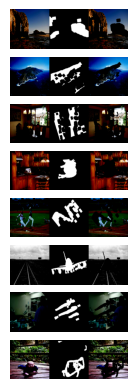

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from src.config.config import cra_config as config


dataset_generator = InpaintDataset(config)
dataset = ds.GeneratorDataset(dataset_generator, ['image'])
dataset_size = len(dataset_generator)
total_batch = dataset_size // config.train_batchsize
dataset = dataset.batch(config.train_batchsize, drop_remainder=True)
dataset = dataset.create_dict_iterator(output_numpy=True)
dataset = next(dataset)
for i, image in enumerate(dataset['image']):
    image = image[(2, 1, 0), :, :]
    image = image.transpose(1, 2, 0)
    mask, mask_show = random_mask(config)
    mask = ops.Squeeze(0)(mask).asnumpy()
    mask = mask.transpose(1, 2, 0)
    real = image * (1-mask)
    result = np.concatenate([image, mask_show, real], 1)
    plt.subplot(8, 1, i+1)
    plt.axis('off')
    plt.imshow(result)
plt.show()


## 创建网络

### 模型架构

在数据加载完成后，我们进行网络模型的整体搭建。
具体来说，我们使用生成对抗网络来预测低分辨率图像修复结果，并对其进行上采样以产生跟待修复图像同样尺寸的模糊图像；通过聚合上下文patches的加权高频残差来生成缺失内容的高频信息；将聚合残差添加到大而模糊的图像中获得清晰修复图像。
接下来，将从部分到整体介绍网络架构。

#### 轻量级门控卷积（LWGC）

综合分析普通卷积和部分卷积对处理不规则空洞区域的缺陷，论文初步采用门控卷积（GC）来搭建模型各卷积层，然而，与普通卷积相比，GC的参数数量和处理时间几乎翻了一倍。因此，该论文提出了三个修改版本的轻量级门控卷积：depth-separable LWGC(LWGCds)、pixelwise LWGC(LWGCpw)、single-channel LWGC(LWGCsc)。

原始GC的输出可以表示为：

$$ G = conv(Wg,I) $$

$$ F = conv(Wf,I) $$

$$ O = \sigma(G)\bigodot\psi(F) $$

其中，$\sigma$为sigmoid函数，$\psi$通常设置为ELU激活函数，$Wg$和$Wf$是两组不同的卷积滤波器。

对于论文提出的三种门控卷积变体不同之处在于分支G的计算：

$$ G = conv^{single-channel}(Wg,I) ，  采用单通道输出 $$

$$ G = conv^{pixelwise}(Wg,I) ，             采用1\times1卷积来计算G $$

$$ G = conv^{depth-separable}(Wg,I) ，采用深度卷积结合1\times1 卷积来计算G $$

这里我们在生成器粗网部分采用LWGCsc门控卷积：

In [5]:
import mindspore.nn as nn
from mindspore.common.initializer import TruncatedNormal


class ScConv(nn.Cell):
    """Build LWGCsc Gate branch"""

    def __init__(self, in_channel, kernel_size, stride, padding, dilation):
        super(ScConv, self).__init__()
        self.single_channel_conv = nn.Conv2d(in_channels=in_channel, out_channels=1, kernel_size=kernel_size,
                                             stride=stride, pad_mode='same', padding=padding, dilation=dilation,
                                             group=1, has_bias=True, weight_init=TruncatedNormal(0.05))

    def construct(self, x):
        x = self.single_channel_conv(x)
        return x


在生成器细网部分采用LWGCds门控卷积：

In [6]:
class DepthSeparableConv(nn.Cell):
    """Build LWGCds Gate branch"""

    def __init__(self, in_channel, out_channel, stride, dilation):
        super(DepthSeparableConv, self).__init__()
        self.ds_conv = nn.Conv2d(in_channels=in_channel, out_channels=out_channel, kernel_size=1, stride=stride,
                                 pad_mode='same', padding=0, dilation=dilation, group=1, has_bias=True,
                                 weight_init=TruncatedNormal(0.05))

    def construct(self, x):
        x = self.ds_conv(x)
        return x


结合nn.Conv2d普通卷积搭建门控卷积网络层：

In [7]:
class GatedConv2d(nn.Cell):
    """Build LWGCsc and LWGCds network layer"""

    def __init__(self, in_channel, out_channel, kernel_size, stride, dilation, sc=False):
        super(GatedConv2d, self).__init__()
        self.activation = nn.ELU(alpha=1.0)
        if sc:
            self.conv2d = nn.Conv2d(in_channel, out_channel, kernel_size, stride, pad_mode='same', padding=0,
                                    dilation=dilation, has_bias=True, weight_init=TruncatedNormal(0.05))
            self.gate_factor = ScConv(in_channel, kernel_size, stride, 0, dilation)
        else:
            self.conv2d = nn.Conv2d(in_channel, out_channel, kernel_size, stride, pad_mode='same', padding=0,
                                    dilation=dilation, has_bias=True, weight_init=TruncatedNormal(0.05))
            self.gate_factor = DepthSeparableConv(in_channel, out_channel, stride, dilation)
        self.sigmoid = nn.Sigmoid()

    def construct(self, x):
        gc_f = self.conv2d(x)
        gc_g = self.gate_factor(x)
        x = self.sigmoid(gc_g) * self.activation(gc_f)
        return x


#### 注意力计算模块（ACM）

注意力分数是根据高级特征图（表示为P）的区域亲和性（region affinity）计算的，P被划分成特定大小的块，通过计算缺失区域内外块之间的余弦相似度来获取相似度分数，具体表示如下：

$$ c_{i,j} = \langle\frac {p_i}{\mid\mid p_i\mid\mid},\frac {p_j}{\mid\mid p_j\mid\mid}\rangle $$

其中，$p_i$是从P中hole外提取的第$i$个patch，$p_j$是从P中hole内提取到的第$j$个patch。

将softmax应用于相似度分数以获取P中每个patch的注意力分数：

$$ s_{i,j} = \frac{e^{c_{i,j}}}{\sum_{i=1}^{N} {e^{c_{i,j}}}} $$

其中，N是P中hole区域外的patches个数。在我们的框架中，采用64$\times$64的高级特征图计算注意力分数，并划分每个patch的大小为3$\times$3，在张量correspondence中保存注意力分数。

In [8]:
from src.models.compute_attention import downsample, InitConv2d


class ContextualAttention(nn.Cell):
    """
    Attention score computing module.

    Args:
        softmax_scale(int): scaled softmax for attention.
        src(Tensor): input feature to match (foreground).
        ref(Tensor): input feature for match (background).
        mask(Tensor): input mask for ref, indicating patches not available.

    Return:
        out: Foreground area filled with context information
             (It generally refers to the 64 * 64 feature map used to calculate attention scores).
        correspondence: Attention score.
    """

    def __init__(self, softmax_scale=10, fuse=True, dtype=mindspore.float32):
        super(ContextualAttention, self).__init__()
        self.softmax_scale = softmax_scale
        self.fuse = fuse
        self.dtype = dtype
        self.reducesum = ops.ReduceSum(False)
        self.unfold1 = nn.Unfold([1, 3, 3, 1], [1, 2, 2, 1], [1, 1, 1, 1], 'same')
        self.unfold2 = nn.Unfold([1, 3, 3, 1], [1, 1, 1, 1], [1, 1, 1, 1], 'same')
        self.transpose = ops.Transpose()
        self.reshape = ops.Reshape()
        self.pool1 = nn.MaxPool2d(16, 16, 'same', 'NCHW')
        self.pool2 = nn.MaxPool2d(3, 1, 'same', 'NCHW')
        self.maximum = ops.Maximum()
        self.sqrt = ops.Sqrt()
        self.square = ops.Square()
        self.eye = ops.Eye()
        self.reducemax = ops.ReduceMax(True)
        self.greaterequal = ops.GreaterEqual()
        self.pow = ops.Pow()
        self.div = ops.Div()
        self.softmax = nn.Softmax(1)
        self.cat = ops.Concat(0)
        self.conv1 = InitConv2d([3, 3, 128, 1024], 1, True)
        self.conv2 = InitConv2d([3, 3, 1, 1], 1, True)
        self.disconv1 = InitConv2d([3, 3, 128, 1024], 2, False)

    def construct(self, src, ref, mask, method='SOFT'):
        """compute attention score"""

        # get shapes
        shape_src = src.shape
        batch_size = shape_src[0]
        nc = shape_src[1]
        # raw features
        raw_feats = self.unfold1(ref)
        raw_feats = self.transpose(raw_feats, (0, 2, 3, 1))
        raw_feats = self.reshape(raw_feats, (batch_size, -1, 3, 3, nc))
        raw_feats = self.transpose(raw_feats, (0, 2, 3, 4, 1))
        split = ops.Split(0, batch_size)
        raw_feats_lst = split(raw_feats)
        # resize
        src = downsample(src)
        ref = downsample(ref)
        ss = src.shape
        rs = ref.shape
        src_lst = split(src)
        feats = self.unfold2(ref)
        feats = self.transpose(feats, (0, 2, 3, 1))
        feats = self.reshape(feats, (batch_size, -1, 3, 3, nc))
        feats = self.transpose(feats, (0, 2, 3, 4, 1))
        feats_lst = split(feats)
        # process mask
        mask = self.pool1(mask)
        mask = self.pool2(mask)
        mask = 1 - mask
        mask = self.reshape(mask, (1, -1, 1, 1))

        y_lst, y_up_lst = [], []
        offsets = []
        fuse_weight = self.reshape(self.eye(3, 3, mindspore.float32), (3, 3, 1, 1))
        for x, r, raw_r in zip(src_lst, feats_lst, raw_feats_lst):
            r = r[0]
            r = r / self.maximum(self.sqrt(self.reducesum(self.square(r), [0, 1, 2])), 1e-8)
            r_kernel = self.transpose(r, (3, 2, 0, 1))
            y = self.conv1(x, r_kernel)
            if self.fuse:
                # conv implementation for fuse scores to encourage large patches
                yi = self.reshape(y, (1, 1, ss[2] * ss[3], rs[2] * rs[3]))
                fuse_weight_kernel = ops.Transpose()(fuse_weight, (3, 2, 0, 1))
                yi = self.conv2(yi, fuse_weight_kernel)
                yi = self.transpose(yi, (0, 2, 3, 1))
                yi = self.reshape(yi, (1, ss[2], ss[3], rs[2], rs[3]))
                yi = self.transpose(yi, (0, 2, 1, 4, 3))
                yi = self.reshape(yi, (1, ss[2] * ss[3], rs[2] * rs[3], 1))
                yi = self.transpose(yi, (0, 3, 1, 2))
                yi = self.conv2(yi, fuse_weight_kernel)
                yi = self.transpose(yi, (0, 2, 3, 1))
                yi = self.reshape(yi, (1, ss[3], ss[2], rs[3], rs[2]))
                yi = self.transpose(yi, (0, 2, 1, 4, 3))
                y = yi
            y = self.reshape(y, (1, ss[2], ss[3], rs[2] * rs[3]))
            y = self.transpose(y, (0, 3, 1, 2))
            if method == 'HARD':
                ym = self.reducemax(y, 1)
                y = y * mask
                coef = self.greaterequal(y, max(y, 1)).astype(self.dtype)
                y = self.pow(coef * self.div(y, ym + 1e-04), 2)
            elif method == 'SOFT':
                y = (self.softmax(y * mask * self.softmax_scale)) * mask
            y = self.reshape(y, (1, rs[2] * rs[3], ss[2], ss[3]))
            if self.dtype == mindspore.float32:
                offset = y.argmax(1)
                offsets.append(offset)
            feats = raw_r[0]
            feats_kernel = self.transpose(feats, (3, 2, 0, 1))
            y_up = self.disconv1(y, feats_kernel)
            y_lst.append(y)
            y_up_lst.append(y_up)
        out, correspondence = self.cat(y_up_lst), self.cat(y_lst)
        out = self.reshape(out, (shape_src[0], shape_src[1], shape_src[2], shape_src[3]))
        return out, correspondence


#### 多尺度注意力转移机制和分数共享（ATM）

从高级特征图P中计算得到注意力分数后，较低级别特征图（$ P^L $）的缺失内容可以应用注意力分数实现上下文patches的加权填充：

$$ {p^l}_j = \sum_{i=1}^{N} {s_{i,j}{p^l}_i} $$

其中，$ l\in1,2,3 $分别对应特征图大小为64,128,256的网络层，$ {p^l}_i $是从hole区域外提取的第$i$个patch，${p^l}_j$是hole区域提取的第$j$个patch，N表示背景区域内所划分的patches数量。由于特征图的大小因层而异，因此各层所划分的patches大小应相应变化。

在该论文框架中，将相同的注意力分数correspondence多次应用到不同的特征图中实现注意力转移，注意力分数的共享导致更少的网络参数以及更高的计算效率。

In [9]:
class ApplyAttention(nn.Cell):
    """
    Attention transfer module(used for training)
    (It generally used for 128 * 128 / 256 * 256 feature map).

    Args:
        shp(list): the shape of input feature map.
        shp_att(list): the shape of attention score.

    Return:
        out: Feature map filled by attention transfer module.
    """

    def __init__(self, shp, shp_att):
        super(ApplyAttention, self).__init__()
        self.shp = shp
        self.shp_att = shp_att
        self.rate = self.shp[2] // self.shp_att[2]
        self.kernel = self.rate * 2
        self.batch_size = self.shp[0]
        self.sz = self.shp[2]
        self.nc = self.shp[1]
        self.unfold = nn.Unfold([1, self.kernel, self.kernel, 1], [1, self.rate, self.rate, 1], [1, 1, 1, 1], 'same')
        self.transpose = ops.Transpose()
        self.reshape = ops.Reshape()
        self.split = ops.Split(0, self.batch_size)
        self.disconv1 = InitConv2d([8, 8, 64, 1024], self.rate, False)
        self.disconv2 = InitConv2d([16, 16, 32, 1024], self.rate, False)
        self.concat = ops.Concat(0)
        self.conv_pl2 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 1),
            GatedConv2d(64, 64, 3, 1, 2)
        )
        self.conv_pl1 = nn.SequentialCell(
            GatedConv2d(32, 32, 3, 1, 1),
            GatedConv2d(32, 32, 3, 1, 2)
        )

    def construct(self, x, correspondence):
        """apply attention on training"""

        raw_feats = self.unfold(x)
        raw_feats = self.transpose(raw_feats, (0, 2, 3, 1))
        raw_feats = self.reshape(raw_feats, (self.batch_size, -1, self.kernel, self.kernel, self.nc))
        raw_feats = self.transpose(raw_feats, (0, 2, 3, 4, 1))
        raw_feats_lst = self.split(raw_feats)
        ys = []
        correspondence = self.transpose(correspondence, (0, 2, 3, 1))
        att_lst = self.split(correspondence)
        for feats, att in zip(raw_feats_lst, att_lst):
            feats_kernel = self.transpose(feats[0], (3, 2, 0, 1))
            att = self.transpose(att, (0, 3, 1, 2))
            if self.shp[2] == 128:
                y1 = self.disconv1(att, feats_kernel)
                ys.append(y1)
            elif self.shp[2] == 256:
                y2 = self.disconv2(att, feats_kernel)
                ys.append(y2)
            else:
                print('Value Error')
        out = self.concat(ys)
        if self.shp[2] == 128:
            out = self.conv_pl2(out)
        elif self.shp[2] == 256:
            out = self.conv_pl1(out)
        else:
            print('conv error')
        return out


#### The Overall Pipeline of CRA

给定一个高分辨率输入图像，首先将图像下采样到512$\times$512（低分辨率图像）,然后对其进行上采样以获得与原始输入相同大小的模糊图像（低频分量）。生成器获取低分辨率图像并进行图像修复，同时，注意力分数由生成器的注意力计算模块（ACM）计算。通过从原始输入中减去模糊低频分量计算图像上下文残差(contextual residual)，然后通过注意力转移模块（ATM）结合注意力分数从上下文残差图像中计算空洞区域的聚合残差(aggregated residual)，最后，将聚合残差添加到上采样的图像修复结果中得到hole区域的最终修复结果，而hole外的区域依旧采用原始输入。
CRA机制整体流程如下图。

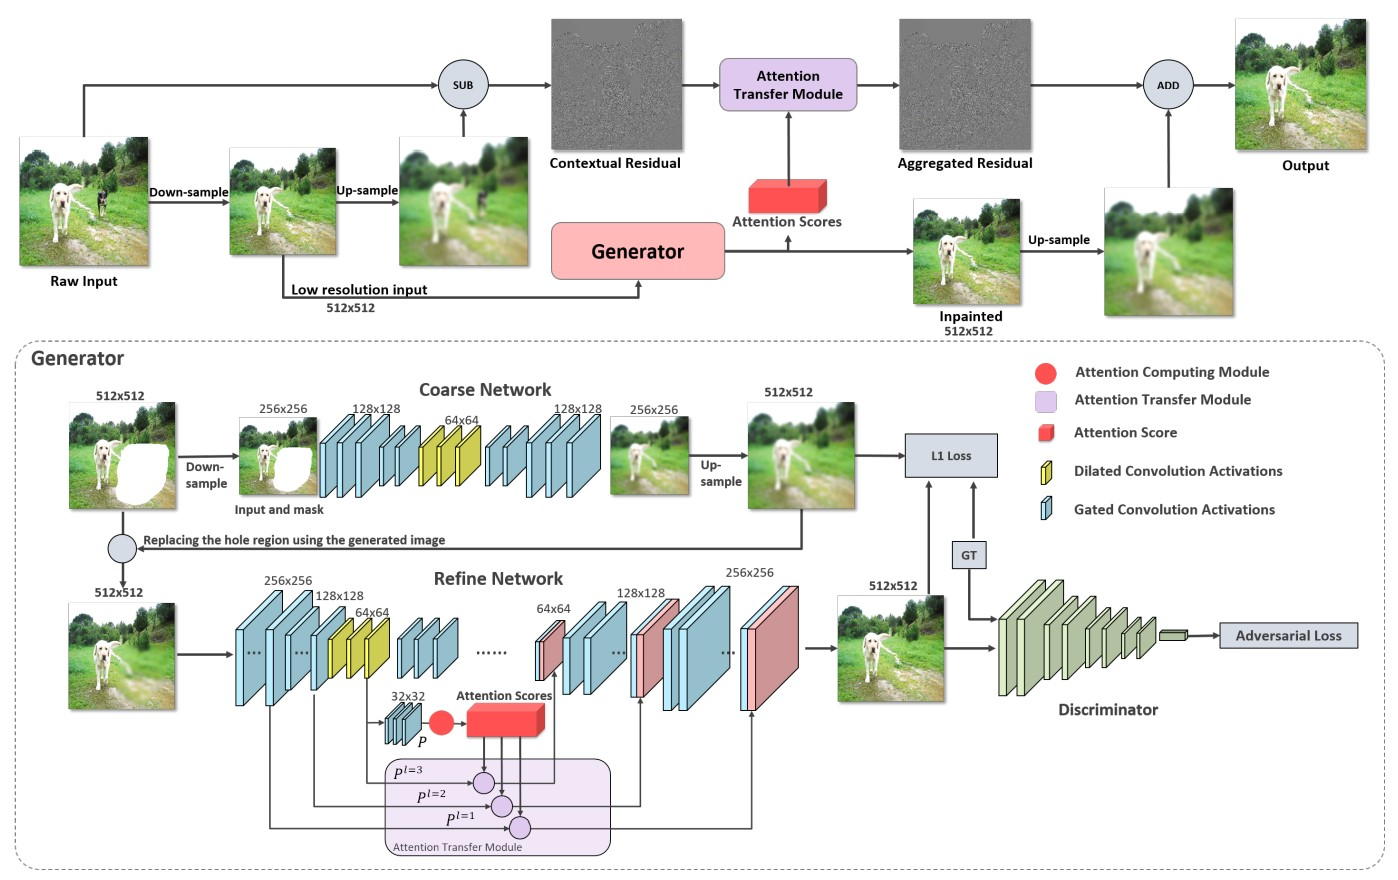

> 图片来源 https://arxiv.org/pdf/2005.09704.pdf

##### 生成器

生成器部分采用两阶段的从粗到细的网络架构，其中粗网生成图像修复的粗糙效果，而细网在粗网的基础上预测更精细的结果。生成器将原始图像和mask图像作为输入并生成一张完整的修复图像，输入和输出大小为512$\times$512。为了扩大感知域并减少计算量，在粗网卷积之前将输入下采样到256$\times$256，而对于细网的输入，则是将输入的hole区域替换为粗网的对应区域。细网使用高级特征图计算上下文注意力分数，并对多个较低级别特征图执行注意力转移，论文还在粗网和细网中采用扩张卷积，进一步扩大感受野的大小。此外，为了提高计算效率，LWGC门控卷积应用于生成器的所有层。对于网络卷积层,统一移除了BN（batch normalization）处理，padding处理采用'same'模式，卷积层的激活函数全部采用ELU激活函数。

In [10]:
from src.models.network_module import GatedConv2d, TransposeGatedConv2d
from src.models.compute_attention import ContextualAttention, ApplyAttention


class Coarse(nn.Cell):
    """Build the first stage of generator: coarse network"""

    def __init__(self):
        super(Coarse, self).__init__()
        self.coarse1 = nn.SequentialCell(
            GatedConv2d(4, 32, 5, 2, 1, sc=True),
            GatedConv2d(32, 32, 3, 1, 1, sc=True),
            GatedConv2d(32, 64, 3, 2, 1, sc=True)
        )
        self.coarse2 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
            GatedConv2d(64, 64, 3, 1, 1, sc=True)
        )
        self.coarse3 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
            GatedConv2d(64, 64, 3, 1, 1, sc=True)
        )
        self.coarse4 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 2, sc=True),
            GatedConv2d(64, 64, 3, 1, 2, sc=True),
            GatedConv2d(64, 64, 3, 1, 2, sc=True),
            GatedConv2d(64, 64, 3, 1, 2, sc=True),
            GatedConv2d(64, 64, 3, 1, 2, sc=True)
        )
        self.coarse5 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 4, sc=True),
            GatedConv2d(64, 64, 3, 1, 4, sc=True),
            GatedConv2d(64, 64, 3, 1, 4, sc=True),
            GatedConv2d(64, 64, 3, 1, 4, sc=True)
        )
        self.coarse6 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 8, sc=True),
            GatedConv2d(64, 64, 3, 1, 8, sc=True),
        )
        self.coarse7 = nn.SequentialCell(
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
            GatedConv2d(64, 64, 3, 1, 1, sc=True),
        )
        self.coarse8 = nn.SequentialCell(
            TransposeGatedConv2d(64, 32, 3, 1, 1, sc=True),
            GatedConv2d(32, 32, 3, 1, 1, sc=True),
            TransposeGatedConv2d(32, 3, 3, 1, 1, sc=True),
        )

    def construct(self, first_in):
        first_out = self.coarse1(first_in)
        first_out = self.coarse2(first_out)
        first_out = self.coarse3(first_out)
        first_out = self.coarse4(first_out)
        first_out = self.coarse5(first_out)
        first_out = self.coarse6(first_out)
        first_out = self.coarse7(first_out)
        first_out = self.coarse8(first_out)
        first_out = ops.clip_by_value(first_out, -1, 1)
        return first_out


class GatedGenerator(nn.Cell):
    """
    Build the second stage of generator: refine network and complete generator.

    Args:
        opt(class): option class.

    Return:
        first_out: The output of coarse network.
        second_out: The output of refine network.
        match: Attention score.
    """

    def __init__(self, opt):
        super(GatedGenerator, self).__init__()
        self.coarse = Coarse()
        self.refinement1 = nn.SequentialCell(
            GatedConv2d(4, 32, 3, 2, 1),
            GatedConv2d(32, 32, 3, 1, 1)
        )
        self.refinement2 = nn.SequentialCell(
            GatedConv2d(32, 64, 3, 2, 1),
            GatedConv2d(64, 64, 3, 1, 1)
        )
        self.refinement3 = nn.SequentialCell(
            GatedConv2d(64, 128, 3, 2, 1),
            GatedConv2d(128, 128, 3, 1, 1)
        )
        self.refinement4 = GatedConv2d(128, 128, 3, 1, 1)
        self.refinement5 = nn.SequentialCell(
            GatedConv2d(128, 128, 3, 1, 2),
            GatedConv2d(128, 128, 3, 1, 4)
        )
        self.refinement6 = nn.SequentialCell(
            GatedConv2d(128, 128, 3, 1, 8),
            GatedConv2d(128, 128, 3, 1, 16)
        )
        self.refinement7 = nn.SequentialCell(
            TransposeGatedConv2d(128, 64, 3, 1, 1),
            GatedConv2d(64, 64, 3, 1, 1)
        )
        self.refinement8 = nn.SequentialCell(
            TransposeGatedConv2d(128, 32, 3, 1, 1),
            GatedConv2d(32, 32, 3, 1, 1)
        )
        self.refinement9 = TransposeGatedConv2d(64, 3, 3, 1, 1)
        self.conv_att1 = GatedConv2d(128, 128, 3, 1, 1)
        self.conv_att2 = GatedConv2d(256, 128, 3, 1, 1)
        self.batch = opt.train_batchsize
        self.apply_attention1 = ApplyAttention([self.batch, 64, 128, 128], [self.batch, 1024, 32, 32])
        self.apply_attention2 = ApplyAttention([self.batch, 32, 256, 256], [self.batch, 1024, 32, 32])
        self.ones = ops.Ones()
        self.concat = ops.Concat(1)
        self.bilinear_256 = ops.ResizeBilinearV2()
        self.bilinear_512 = ops.ResizeBilinearV2()
        self.reshape = ops.Reshape()
        self.contextual_attention = ContextualAttention(fuse=True, dtype=mindspore.float32)
        self.cat = ops.Concat(1)
        self.method = opt.attention_type

    def construct(self, img, mask):
        x_in = img.astype(mindspore.float32)
        shape = x_in.shape
        mask_batch = self.ones((shape[0], 1, shape[2], shape[3]), mindspore.float32)
        mask_batch = mask_batch * mask
        first_in = self.concat((x_in, mask_batch))
        first_in = self.bilinear_256(first_in, (256, 256))
        first_out = self.coarse(first_in)
        first_out = self.bilinear_512(first_out, (512, 512))
        first_out = self.reshape(first_out, (shape[0], shape[1], shape[2], shape[3]))
        x_coarse = first_out * mask_batch + x_in * (1. - mask_batch)
        second_in = self.concat([x_coarse, mask_batch])
        pl1 = self.refinement1(second_in)
        pl2 = self.refinement2(pl1)
        second_out = self.refinement3(pl2)
        second_out = self.refinement4(second_out)
        second_out = self.refinement5(second_out)
        pl3 = self.refinement6(second_out)
        x_hallu = pl3
        x, match = self.contextual_attention(pl3, pl3, mask, self.method)
        x = self.conv_att1(x)
        x = self.cat((x_hallu, x))
        second_out = self.conv_att2(x)
        second_out = self.refinement7(second_out)
        second_out_att = self.apply_attention1(pl2, match)
        second_out = self.concat([second_out_att, second_out])
        second_out = self.refinement8(second_out)
        second_out_att = self.apply_attention2(pl1, match)
        second_out = self.concat([second_out_att, second_out])
        second_out = self.refinement9(second_out)
        second_out = ops.clip_by_value(second_out, -1, 1)
        return first_out, second_out, match


##### 判别器

判别器D通过一系列的Conv2d和LeakyReLU层对其进行处理，最后通过nn.Dense函数输出最终判别结果。判别器的代码实现如下：

In [11]:
from src.models.network_module import Conv2dLayer


class Discriminator(nn.Cell):
    """Build the complete discriminator"""

    def __init__(self):
        super(Discriminator, self).__init__()
        self.block1 = Conv2dLayer(3, 64, 5, 2, 1)
        self.block2 = Conv2dLayer(64, 128, 5, 2, 1)
        self.block3 = Conv2dLayer(128, 256, 5, 2, 1)
        self.block4 = Conv2dLayer(256, 256, 5, 2, 1)
        self.block5 = Conv2dLayer(256, 256, 5, 2, 1)
        self.block6 = Conv2dLayer(256, 256, 5, 2, 1)
        self.block7 = nn.Dense(16384, 1)

    def construct(self, img):
        x = img
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = x.reshape([x.shape[0], -1])
        x = self.block7(x)
        return x


### 构建连接网络和损失函数

mindspore将损失函数、优化器等操作都封装到了Cell中，这种设计给实现GAN带来了一些不方便。因为GAN结构上的特殊性，它和一般的分类网络不同，损失由判别器损失和生成器损失组成，是多输出的。如果直接使用Cell包，框架会不知道Loss和网络是如何连接的，会导致无法训练。所以，我们需要自定义WithLossCell，将网络和Loss连接起来。

对于生成器损失，我们分别构建了对抗性损失$L_{adv}$和重建损失$L_{rec}$：

$$ L_{adv} = - E_{\breve{x}\in P_{g}}[D(\breve{x})] $$

$$ L_{in-hole} = \alpha E[|C(x,m) - x| \bigodot m] + E[|G(x,m) - x| \bigodot m]$$

$$ L_{context} = \alpha E[|C(x,m) - x| \bigodot (1-m)] + E[|G(x,m) - x| \bigodot (1-m)]$$

$$ L_{rec} = \alpha_1 L_{in-hole} + \alpha_2 L_{context}  $$

$$L_g = \beta L_{adv} + L_{rec}$$

其中，$\alpha$ 一般取1.2，$\alpha_1$ 取1.2，$\alpha_2$ 取1.2，$\beta$ 取0.001.

In [12]:
from src.models.cra_utils.utils import gan_wgan_loss


class GenWithLossCell(nn.Cell):
    """
    Build the generator loss.

    Args:
        net_g(cell): generator network.
        net_d(cell): discriminator network.
        args(class): option class.
        auto_prefix(bool): whether to automatically generate namespace for cell and its subcells.
            If set to True, the network parameter name will be prefixed, otherwise it will not.

    Return:
        loss_g: the loss of generator.
    """

    def __init__(self, net_g, net_d, args, auto_prefix=True):
        super(GenWithLossCell, self).__init__(auto_prefix=auto_prefix)
        self.net_g = net_g
        self.net_d = net_d
        self.gan_wgan_loss = gan_wgan_loss
        self.coarse_alpha = args.coarse_alpha
        self.gan_with_mask = args.gan_with_mask
        self.gan_loss_alpha = args.gan_loss_alpha
        self.in_hole_alpha = args.in_hole_alpha
        self.context_alpha = args.context_alpha
        self.train_batchsize = args.train_batchsize
        self.mean = ops.ReduceMean(False)
        self.abs = ops.Abs()
        self.concat_0 = ops.Concat(0)
        self.concat_1 = ops.Concat(1)
        self.split = ops.Split(0, 2)
        self.tile = ops.Tile()

    def construct(self, real, x, mask):
        x1, x2, _ = self.net_g(x, mask)
        fake = x2
        losses = {}
        fake_patched = fake * mask + real * (1 - mask)
        fake_patched = fake_patched.astype(mindspore.float32)
        losses['in_hole_loss'] = self.coarse_alpha * self.mean(self.abs(real - x1) * mask)
        losses['in_hole_loss'] = losses['in_hole_loss'] + self.mean(self.abs(real - x2) * mask)
        losses['context_loss'] = self.coarse_alpha * self.mean(self.abs(real - x1) * (1 - mask))
        losses['context_loss'] = losses['context_loss'] + self.mean(self.abs(real - x2) * (1 - mask))
        losses['context_loss'] = losses['context_loss'] / self.mean(1 - mask)
        real_fake = self.concat_0((real, fake_patched))
        if self.gan_with_mask:
            real_fake = self.concat_1((real_fake, self.tile(mask, (self.train_batchsize * 2, 1, 1, 1))))
        d_real_fake = self.net_d(real_fake)
        d_real, d_fake = self.split(d_real_fake)
        g_loss, _ = self.gan_wgan_loss(d_real, d_fake)
        losses['adv_gloss'] = g_loss
        losses['g_loss'] = self.gan_loss_alpha * losses['adv_gloss']
        losses['g_loss'] = losses['g_loss'] + self.in_hole_alpha * losses['in_hole_loss']
        losses['g_loss'] = losses['g_loss'] + self.context_alpha * losses['context_loss']
        loss_g = losses['g_loss']
        return loss_g


对于判别器损失，我们加入了WGAN-GP loss，加强了第二阶段细化网络的全局一致性：

$$ L_d = E_{\breve{x}\in P_{g}}[D(\breve{x})] - E_{x\in P_{r}}[D(x)] + \sigma E_{\hat{x}\in P_{\hat{x}}}[\mid\mid\nabla_{\hat{x}}D(\hat{x})\mid\mid_{2}-1]^2 $$

其中，$D(.)$是判别器输出，$G(.)$是生成器输出，$x,\breve{x},\hat{x}$分别是真实图像、生成图像以及它们之间的插值interpolations，$P_{g},P_{r},P_{\hat{x}}$分别是它们对应的分布。

In [13]:
from src.models.cra_utils.utils import random_interpolates, GradientsPenalty


class DisWithLossCell(nn.Cell):
    """
    Build the discriminator loss.

    Args:
        net_g(cell): generator network.
        net_d(cell): discriminator network.
        args(class): option class.
        auto_prefix(bool): whether to automatically generate namespace for cell and its subcells.
            If set to True, the network parameter name will be prefixed, otherwise it will not.

    Return:
        loss_d: the loss of discriminator.
    """

    def __init__(self, net_g, net_d, args, auto_prefix=True):
        super(DisWithLossCell, self).__init__(auto_prefix=auto_prefix)
        self.net_g = net_g
        self.net_d = net_d
        self.gan_wgan_loss = gan_wgan_loss
        self.random_interpolates = random_interpolates
        self.gradients_penalty = GradientsPenalty(self.net_d)
        self.gan_with_mask = args.gan_with_mask
        self.wgan_gp_lambda = args.wgan_gp_lambda
        self.train_batchsize = args.train_batchsize
        self.concat_0 = ops.Concat(0)
        self.concat_1 = ops.Concat(1)
        self.split = ops.Split(0, 2)

    def construct(self, real, x, mask):
        _, x2, _ = self.net_g(x, mask)
        fake = x2
        losses = {}
        fake_patched = fake * mask + real * (1 - mask)
        fake_patched = fake_patched.astype(mindspore.float32)
        real_fake = self.concat_0((real, fake_patched))
        if self.gan_with_mask:
            real_fake = self.concat_1((real_fake, ops.Tile()(mask, (self.train_batchsize * 2, 1, 1, 1))))
        d_real_fake = self.net_d(real_fake)
        d_real, d_fake = self.split(d_real_fake)
        _, d_loss = self.gan_wgan_loss(d_real, d_fake)
        losses['adv_dloss'] = d_loss
        interps = self.random_interpolates(real, fake_patched)
        gp_loss = self.gradients_penalty(interps)
        losses['gp_loss'] = self.wgan_gp_lambda * gp_loss
        losses['d_loss'] = losses['adv_dloss'] + losses['gp_loss']
        loss_d = losses['d_loss']
        return loss_d


搭建损失函数与网络的连接，定义训练网络封装类：

In [14]:
import mindspore.ops.functional as F
from mindspore.parallel._utils import (_get_device_num, _get_gradients_mean, _get_parallel_mode)
from mindspore.context import ParallelMode
from mindspore.nn.wrap.grad_reducer import DistributedGradReducer


class TrainOneStepD(nn.Cell):
    """Encapsulation class of discriminator network training."""

    def __init__(self, d, optimizer, sens=1.0):
        super(TrainOneStepD, self).__init__(auto_prefix=True)
        self.optimizer = optimizer
        self.d = d
        self.d.net_d.set_grad()
        self.d.net_d.set_train()
        self.d.net_g.set_grad(False)
        self.d.net_g.set_train(False)
        self.grad = ops.GradOperation(get_by_list=True, sens_param=True)
        self.sens = sens
        self.weights = optimizer.parameters
        self.reducer_flag = False
        self.fill = ops.Fill()
        self.dtype = ops.DType()
        self.shape = ops.Shape()
        self.grad_reducer = F.identity
        self.parallel_mode = _get_parallel_mode()
        if self.parallel_mode in (ParallelMode.DATA_PARALLEL, ParallelMode.HYBRID_PARALLEL):
            self.reducer_flag = True
        if self.reducer_flag:
            mean = _get_gradients_mean()
            degree = _get_device_num()
            self.grad_reducer = DistributedGradReducer(self.weights, mean, degree)

    def construct(self, real, x, mask):
        weights = self.weights
        loss_d = self.d(real, x, mask)
        sens_d = self.fill(self.dtype(loss_d), self.shape(loss_d), self.sens)
        grads_d = self.grad(self.d, weights)(real, x, mask, sens_d)
        if self.reducer_flag:
            grads_d = self.grad_reducer(grads_d)
        self.optimizer(grads_d)
        return loss_d


class TrainOneStepG(nn.Cell):
    """Encapsulation class of generator network training."""

    def __init__(self, g, optimizer, sens=1.0):
        super(TrainOneStepG, self).__init__(auto_prefix=True)
        self.optimizer = optimizer
        self.g = g
        self.g.net_g.set_grad()
        self.g.net_g.set_train()
        self.g.net_d.set_grad(False)
        self.g.net_d.set_train(False)
        self.grad = ops.GradOperation(get_by_list=True, sens_param=True)
        self.sens = sens
        self.weights = optimizer.parameters
        self.reducer_flag = False
        self.fill = ops.Fill()
        self.dtype = ops.DType()
        self.shape = ops.Shape()
        self.grad_reducer = F.identity
        self.parallel_mode = _get_parallel_mode()
        if self.parallel_mode in (ParallelMode.DATA_PARALLEL, ParallelMode.HYBRID_PARALLEL):
            self.reducer_flag = True
        if self.reducer_flag:
            mean = _get_gradients_mean()
            degree = _get_device_num()
            self.grad_reducer = DistributedGradReducer(self.weights, mean, degree)

    def construct(self, real, x, mask):
        weights = self.weights
        loss_g = self.g(real, x, mask)
        sens_g = self.fill(self.dtype(loss_g), self.shape(loss_g), self.sens)
        grads_g = self.grad(self.g, weights)(real, x, mask, sens_g)
        if self.reducer_flag:
            grads_g = self.grad_reducer(grads_g)
        self.optimizer(grads_g)
        return loss_g


### 构建优化器

In [15]:
net_g = GatedGenerator(config)
net_d = Discriminator()
lr = nn.exponential_decay_lr(config.learning_rate, config.lr_decrease_factor, total_batch * config.epochs, total_batch,
                             config.lr_decrease_epoch, True)
optimizer_g = nn.Adam(filter(lambda p: p.requires_grad, net_g.trainable_params()), lr, 0.5, 0.9)
optimizer_d = nn.Adam(net_d.trainable_params(), lr, 0.5, 0.9)


这里我们设置了两个单独的优化器，分别用于判别器和生成器，参数设定统一 beta1=0.5, beta2=0.9,学习率采用指数衰减函数自动更新。

## 训练模型

训练分为两个主要部分：训练判别器和训练生成器。训练判别器的作用是为了能够更好的识别真伪，尽量把生成器生成的图片和真实的图片分别开来；训练生成器的作用是为了尽量生成近似真实的虚假图片。

训练过程：

In [16]:
import cv2
import time

from mindspore import context, save_checkpoint, nn

from src.config.config import cra_config
from src.models.inpainting_network import GatedGenerator, Discriminator
from src.models.loss import GenWithLossCell, DisWithLossCell
from src.models.train_one_step import TrainOneStepD, TrainOneStepG
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

def trainer(args):
    """Train model."""

    # Preprocess the data for training
    context.set_context(mode=context.GRAPH_MODE, device_target='GPU')
    dataset_generator = InpaintDataset(args)
    dataset_size = len(dataset_generator)
    total_batch = dataset_size // args.train_batchsize
    dataset = ds.GeneratorDataset(dataset_generator, ['image'])
    dataset = dataset.batch(args.train_batchsize, drop_remainder=True)
    dataset = dataset.create_dict_iterator()

    # Network
    net_g = GatedGenerator(args)
    net_d = Discriminator()
    netg_with_loss = GenWithLossCell(net_g, net_d, args)
    netd_with_loss = DisWithLossCell(net_g, net_d, args)
    lr = nn.exponential_decay_lr(args.learning_rate, args.lr_decrease_factor, total_batch * 10, total_batch,
                                 args.lr_decrease_epoch, True)
    optimizer_g = nn.Adam(filter(lambda p: p.requires_grad, net_g.trainable_params()), lr, 0.5, 0.9)
    optimizer_d = nn.Adam(net_d.trainable_params(), lr, 0.5, 0.9)
    train_discriminator = TrainOneStepD(netd_with_loss, optimizer_d)
    train_generator = TrainOneStepG(netg_with_loss, optimizer_g)

    # Train
    train_discriminator.set_train()
    train_generator.set_train()
    print("Starting Training Loop...")
    for epoch in range(200):
        for batch_idx, image in enumerate(dataset):
            s = time.time()
            real = image['image']
            real = real.astype(mindspore.float32)
            mask, _ = random_mask(args)
            x = real * (1 - mask)
            for _ in range(args.dis_iter):
                netd_loss = train_discriminator(real, x, mask)
            netg_loss = train_generator(real, x, mask)
            gap = time.time() - s
            # Print losses
            print('epoch{}/{}, batch{}/{}, d_loss is {:.4f}, g_loss is {:.4f}, time is {:.4f}'.format(
                epoch + 1, args.epochs, batch_idx + 1, total_batch, netd_loss.asnumpy(), netg_loss.asnumpy(), gap))
            save_checkpoint_path = './ckpt_out'
            if not os.path.isdir(save_checkpoint_path):
                os.makedirs(save_checkpoint_path)
            # Save checkpoint
            gen_name = 'generator_epoch%d_batch%d.ckpt' % (epoch + 1, batch_idx + 1)
            dis_name = 'discriminator_epoch%d_batch%d.ckpt' % (epoch + 1, batch_idx + 1)
            gen_name = os.path.join(save_checkpoint_path, gen_name)
            dis_name = os.path.join(save_checkpoint_path, dis_name)
            if (batch_idx + 1) == total_batch:
                save_checkpoint(train_generator, gen_name)
                save_checkpoint(train_discriminator, dis_name)
trainer(cra_config)


[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:04.159.502 [mindspore/context.py:1401] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:04.957.736 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:04.958.807 [mindspore/dataset/core/validator_helpers.py:744] 'CenterCrop' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'CenterCrop' from mindspore.dataset.vision instead.


Starting Training Loop...


[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:14.582.204 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:14.583.208 [mindspore/dataset/core/validator_helpers.py:744] 'CenterCrop' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'CenterCrop' from mindspore.dataset.vision instead.


epoch1/5000, batch1/2, d_loss is 1128.7966, g_loss is 1.1719, time is 9.6203
epoch1/5000, batch2/2, d_loss is 1033.5724, g_loss is 1.4853, time is 1.6439


[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:16.569.904 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:16.570.976 [mindspore/dataset/core/validator_helpers.py:744] 'CenterCrop' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'CenterCrop' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:18.238.706 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:1298092

...

epoch9/5000, batch1/2, d_loss is 580.0038, g_loss is 1.3775, time is 1.6558
epoch9/5000, batch2/2, d_loss is 599.1101, g_loss is 1.2867, time is 1.6405


[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:45.789.219 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:45.790.282 [mindspore/dataset/core/validator_helpers.py:744] 'CenterCrop' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'CenterCrop' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:47.379.012 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:1298092

epoch10/5000, batch1/2, d_loss is 593.7003, g_loss is 1.2875, time is 1.5731
epoch10/5000, batch2/2, d_loss is 568.2607, g_loss is 1.3230, time is 1.4935


[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:49.262.126 [mindspore/dataset/core/validator_helpers.py:744] 'RandomHorizontalFlip' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'RandomHorizontalFlip' from mindspore.dataset.vision instead.
[WARNING] ME(695152:129809264592704,MainProcess):2025-05-16-17:08:49.263.173 [mindspore/dataset/core/validator_helpers.py:744] 'CenterCrop' from mindspore.dataset.vision.c_transforms is deprecated from version 1.8 and will be removed in a future version. Use 'CenterCrop' from mindspore.dataset.vision instead.
/home/jenkins/agent-working-dir/workspace/Compile_GPU_X86_CentOS_Cuda11.6_PY39/mindspore/mindspore/ops/kernel/gpu/cuda_impl/cuda_ops/gather.cu:37: GatherKernel: block: [0,0,0], thread: [0,0,0] Assertion `indices[j] < input_dim1` failed.
[ERROR] DEVICE(695152,760ceaffd6c0,python):2025-05-16-17:08:49.456.665 [mindspore/ccsrc/plugin/res_manager/gpu/device/cud

RuntimeError: Sync stream failed:GPU_0

----------------------------------------------------
- C++ Call Stack: (For framework developers)
----------------------------------------------------
mindspore/ccsrc/runtime/graph_scheduler/graph_scheduler.cc:1297 Run


## 模型推理

在完成生成对抗网络训练后，我们可以使用GAN网络来预测低分辨率图像的修复结果，但要生成一张完整的高分辨率的修复图像，我们还需要做一些后处理操作，具体为：获取图像上下文残差信息；通过高频残差和注意力机制来生成缺失内容的聚合残差；对GAN网络生成图像进行上采样；将聚合残差添加到大而模糊的生成图像中获得清晰修复图像；将修复图像处理到与原始待修复图像同样尺寸。

In [17]:
import glob
import cv2
import numpy as np


def sort(str_lst):
    """Return the sorted list in ascending order."""

    return [s for s in sorted(str_lst)]


def read_imgs_masks(args):
    """Sort the image and mask directories in order and return it."""

    paths_img = glob.glob(args.image_dir + '/*.*[g|G]')
    paths_img = sort(paths_img)
    paths_mask = glob.glob(args.mask_dir + '/*.*[g|G]')
    paths_mask = sort(paths_mask)
    return paths_img, paths_mask


def get_input(path_img, path_mask):
    """Read and process the image and mask through the given path."""

    image = cv2.imread(path_img)
    mask = cv2.imread(path_mask)
    image = np.expand_dims(image, 0)
    mask = np.expand_dims(mask, 0)
    return image[0], mask[0]


In [18]:
from mindspore import nn, ops

from src.models.inpainting_network import GatedGenerator
from src.models.compute_attention import ApplyAttention2


def post_processing(large_img, small_img, low_base, small_mask, corres, args):
    """Subtracting the large blurry image from the raw input to compute contextual residuals,
     and calculate aggregated residuals through attention transfer module.
     Adding the aggregated residuals to the up-sampled generator inpainted result."""

    high_raw = large_img
    # 使用ops.ResizeBilinearV2缩放small_img
    resize_op = ops.ResizeBilinearV2()
    scale_factor = args.times
    input_shape = ops.Shape()(small_img)
    output_h = int(input_shape[2] * scale_factor)
    output_w = int(input_shape[3] * scale_factor)
    low_raw = resize_op(small_img, size=(output_h, output_w))
    
    mask = 1 - small_mask
    to_shape = list(ops.Shape()(mask))[2:]
    to_shape[0], to_shape[1] = int(to_shape[0] * args.times), int(to_shape[1] * args.times)
    resize = ops.ResizeNearestNeighbor((to_shape[0], to_shape[1]))
    mask = resize(mask)
    
    residual1 = (high_raw - low_raw) * mask
    residual = ApplyAttention2([1, 3, 4096, 4096], [1, 1024, 32, 32])(residual1, corres)
    
    # 错误: low_base = nn.ResizeBilinear()(low_base, scale_factor=args.times)
    # 修复: 使用ops.ResizeBilinearV2缩放low_base
    low_base_shape = ops.Shape()(low_base)
    low_base_output_h = int(low_base_shape[2] * scale_factor)
    low_base_output_w = int(low_base_shape[3] * scale_factor)
    low_base = resize_op(low_base, size=(low_base_output_h, low_base_output_w))
    
    x = low_base + residual
    x = x.clip(-1, 1)
    x = (x + 1.) * 127.5
    return x, low_raw, low_base, residual


In [20]:
from scipy import signal

import mindspore
from mindspore import Tensor


import numpy as np
from mindspore import Tensor, ops

def gaussian_kernel(size, std):
    """Return a gaussian kernel."""
    
    # 创建一维高斯分布
    x = np.arange(-(size // 2), (size // 2) + 1)
    # 计算高斯函数值
    gauss = np.exp(-0.5 * np.square(x) / np.square(std))
    # 归一化
    gauss = gauss / np.sum(gauss)
    
    # 创建二维高斯核
    kk = np.outer(gauss, gauss)
    return kk / np.sum(kk)

def resize_back(raw_img, large_output, small_mask):
    """
    Process the test output result in the format of [1, 3,4096,4096] to the same size as the original input image.
    """
    raw_shp = raw_img.shape
    resize_op = ops.ResizeBilinearV2()  # 使用ops模块中的ResizeBilinearV2
    raw_size_output = resize_op(large_output, (raw_shp[2], raw_shp[3]))
    raw_size_output = raw_size_output.astype(mindspore.float32)
    gauss_kernel = gaussian_kernel(7, 1.)
    gauss_kernel = Tensor(gauss_kernel)
    gauss_kernel = gauss_kernel.astype(mindspore.float32)
    gauss_kernel = ops.ExpandDims()(gauss_kernel, 2)
    gauss_kernel = ops.ExpandDims()(gauss_kernel, 3)
    a, b, c, d = ops.Shape()(gauss_kernel)
    gauss_kernel = ops.Transpose()(gauss_kernel, (3, 2, 0, 1))
    conv = nn.Conv2d(c, d, (a, b), 1, pad_mode='same', padding=0, weight_init=gauss_kernel, data_format='NCHW')
    mask = conv(small_mask[:, 0:1, :, :])
    mask = resize_op(mask, (raw_shp[2], raw_shp[3]))  # 这里使用之前定义的resize_op
    mask = mask.astype(mindspore.float32)
    raw_size_output = raw_size_output * mask + raw_img * (1 - mask)
    raw_size_output = ops.Transpose()(raw_size_output, (0, 2, 3, 1))
    raw_size_output = raw_size_output.astype(mindspore.uint8)
    return raw_size_output


In [21]:
def build_inference_graph(real, mask, model_gen):
    """Input real and mask to generator and output the results."""

    mask = mask[0:1, 0:1, :, :]
    x = real * (1. - mask)
    _, x2, corres = model_gen(x, mask)
    fake = x2
    fake_patched = fake * mask + x * (1 - mask)
    return x2, fake_patched, corres


def build_inference_net(raw_img_ph, raw_mask_ph, model_gen, args):
    """
    Complete CRA network testing model, including image preprocessing, generator generation and output,
        and image post-processing operations.

    Args:
        raw_img_ph(Tensor): image read from folder.
            It is processed into the format of [1,3,512,512], the data type is float32, and normalized.
        raw_mask_ph(Tensor): mask read from folder.
            It is processed into the format of [1,3,512,512], the data type is float32, and normalized.
        model_gen(cell): generation network.
        args(class): option class.

    Return:
        raw_size_output: Large test output results.
        raw_img_ph: Image read from folder.
        raw_mask_ph: Mask read from folder.
    """

    # Process input image
    raw_img = ops.ExpandDims()(raw_img_ph, 0)
    raw_img = raw_img.astype(mindspore.float32)
    raw_img = ops.Transpose()(raw_img, (0, 3, 1, 2))
    resize = ops.ResizeNearestNeighbor((args.times * args.input_size, args.times * args.input_size))
    large_img = resize(raw_img)
    large_img = ops.Reshape()(large_img, (1, 3, args.times * args.input_size, args.times * args.input_size))
    large_img = large_img / 127.5 - 1
    net = nn.Unfold([1, args.times, args.times, 1], [1, args.times, args.times, 1], [1, 1, 1, 1], 'same')
    small_img = net(large_img)
    small_img = ops.Transpose()(small_img, (0, 2, 3, 1))
    small_img = ops.Reshape()(small_img, (1, args.input_size, args.input_size, args.times, args.times, 3))
    small_img = ops.ReduceMean(False)(small_img, axis=(3, 4))
    small_img = ops.Transpose()(small_img, (0, 3, 1, 2))
    # Process input mask
    raw_mask = ops.ExpandDims()(raw_mask_ph, 0)
    raw_mask = raw_mask.astype(mindspore.float32)
    raw_mask = ops.Transpose()(raw_mask, (0, 3, 1, 2))
    resize = ops.ResizeNearestNeighbor((args.input_size, args.input_size))
    small_mask = resize(raw_mask)
    small_mask = ops.Reshape()(small_mask, (1, 3, args.input_size, args.input_size))
    small_mask = 1 - small_mask / 255
    # Input image and mask to genenrator
    x2, _, corres = build_inference_graph(real=small_img, mask=small_mask, model_gen=model_gen)
    # Post processing
    large_output, _, _, _ = post_processing(large_img, small_img, x2, small_mask, corres, args)
    # Resize back
    raw_size_output = resize_back(raw_img, large_output, small_mask)
    return raw_size_output, raw_img_ph, raw_mask_ph


推理代码如下：

In [23]:
import os
import time
import argparse
import progressbar

from mindspore import context, load_checkpoint, load_param_into_net
import os  
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  

def parse_args():
    """Parse parameters."""

    parser = argparse.ArgumentParser()
    parser.add_argument('--image_dir', default='/home/yyy/桌面/BS1.0/CRA/test/images', type=str, help='The directory of images to be tested.')
    parser.add_argument('--mask_dir', default='/home/yyy/桌面/BS1.0/CRA/test/masks', type=str, help='The directory of masks.')
    parser.add_argument('--output_dir', default='./output', type=str, help='Where to write testing output.')
    parser.add_argument('--checkpoint_dir', default='/home/yyy/桌面/BS1.0/cra_fuse_disabled_ckpt0/generator_epoch2_batch2000.ckpt', type=str,
                        help='The directory of loading checkpoint.')
    parser.add_argument('--attention_type', default='SOFT', type=str, help='compute attention type.')
    parser.add_argument('--train_batchsize', default=1, type=int, help='Batch size for testing.')
    parser.add_argument('--input_size', default=512, type=int, help='The image size of the input network in the test.')
    parser.add_argument('--times', default=8, type=int, help='The scaling size of input image.')
    return parser.parse_args(args=[])


# setting test data
cra_config = parse_args()
img_paths, mask_paths = read_imgs_masks(cra_config)
if not os.path.exists(cra_config.output_dir):
    os.makedirs(cra_config.output_dir)
total_time = 0
bar = progressbar.ProgressBar(maxval=len(img_paths), widgets=[progressbar.Bar('=', '[', ']'), ' ',
                                                              progressbar.Percentage()])
bar.start()
# load net and checkpoint file
gen = GatedGenerator(cra_config)
param_dict = load_checkpoint(cra_config.checkpoint_dir)
load_param_into_net(gen, param_dict)
#test
for (i, img_path) in enumerate(img_paths):
    rint = i % len(mask_paths)
    bar.update(i + 1)
    img_test, mask_test = get_input(img_path, mask_paths[rint])
    s = time.time()
    input_img_ph = Tensor(img_test)
    input_mask_ph = Tensor(255 - mask_test)
    outputs, input_img_ph, input_mask_ph = build_inference_net(input_img_ph, input_mask_ph, gen, cra_config)
    res = outputs[0]
    res = res.asnumpy()
    total_time += time.time() - s
    img_hole = img_test * (1 - mask_test / 255) + mask_test
    res = np.concatenate([img_test, img_hole, res], axis=1)
    cv2.imwrite(cra_config.output_dir + '/' + str(i) + '.jpg', res)
    print('test finish')
bar.finish()
print('average time per image', total_time / len(img_paths))


[WARNING] ME(6897:127681310103360,MainProcess):2025-04-08-20:59:31.554.07 [mindspore/train/serialization.py:1851] For 'load_param_into_net', remove parameter prefix name: g.net_g., continue to load.
[WARNING] ME(6897:127681310103360,MainProcess):2025-04-08-20:59:31.568.27 [mindspore/train/serialization.py:1761] For 'load_param_into_net', 2 parameters in the 'net' are not loaded, because they are not in the 'parameter_dict', please check whether the network structure is consistent when training and loading checkpoint.
[WARNING] ME(6897:127681310103360,MainProcess):2025-04-08-20:59:31.572.78 [mindspore/train/serialization.py:1765] ['final_layers.0.weight', 'final_layers.1.weight'] are not loaded.


test finish


test finish
average time per image 0.23025298118591309
